# 🏦 Home Credit — Diagnostic complet des données (EDA)

**Étape 1 — Préparation & compréhension des données**

Ce notebook couvre :
- Vue d'ensemble de chaque fichier source (7 CSV)
- Qualité des données : nulls, doublons, types
- Distribution de la variable cible (TARGET)
- Analyse bivariée : features vs défaut
- Corrélations et matrices
- Visualisation des vues SQL (v_clean, v_agg, v_master, v_features_engineering)
- Synthèse : points d'attention pour la modélisation


## 0. Imports & Configuration

In [1]:
import sys
import warnings
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.ticker  as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)

# ── Chemins ──────────────────────────────────────────────────
PROJECT_ROOT = Path(".").resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_RAW  = PROJECT_ROOT / "data" / "raw"
DATA_PROC = PROJECT_ROOT / "data" / "processed"

sys.path.insert(0, str(PROJECT_ROOT))

# ── Style graphiques ─────────────────────────────────────────
PALETTE   = {"défaut": "#e74c3c", "remboursé": "#2ecc71"}
C_DEF     = "#e74c3c"
C_OK      = "#2ecc71"
C_BLUE    = "#3498db"
C_DARK    = "#2c3e50"
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13,
                     "axes.labelsize": 11, "font.family": "DejaVu Sans"})

print(f"✅ Projet racine : {PROJECT_ROOT}")
print(f"✅ Données raw   : {DATA_RAW}")


✅ Projet racine : C:\Users\Public\IAE_DELL\pra_dell\m6_ocr
✅ Données raw   : C:\Users\Public\IAE_DELL\pra_dell\m6_ocr\data\raw


## 1. Chargement des fichiers sources

Le dataset Home Credit comprend **7 fichiers CSV** :

| Fichier | Description | Granularité |
|---------|-------------|-------------|
| `application_train/test` | Demande de crédit principale | 1 ligne / client |
| `bureau` | Historique crédits externes (Bureau de crédit) | N lignes / client |
| `bureau_balance` | Statut mensuel des crédits bureau | N lignes / crédit |
| `previous_application` | Demandes précédentes chez Home Credit | N lignes / client |
| `POS_CASH_balance` | Soldes mensuels POS & cash | N lignes / contrat |
| `credit_card_balance` | Soldes mensuels carte de crédit | N lignes / contrat |
| `installments_payments` | Historique paiements d'échéances | N lignes / paiement |


In [2]:
FICHIERS = {
    "application_train"    : "application_train.csv",
    "application_test"     : "application_test.csv",
    "bureau"               : "bureau.csv",
    "bureau_balance"       : "bureau_balance.csv",
    "previous_application" : "previous_application.csv",
    "POS_CASH_balance"     : "POS_CASH_balance.csv",
    "credit_card_balance"  : "credit_card_balance.csv",
    "installments_payments": "installments_payments.csv",
}

dfs = {}
for nom, fichier in FICHIERS.items():
    chemin = DATA_RAW / fichier
    if chemin.exists():
        dfs[nom] = pd.read_csv(chemin, low_memory=False)
        print(f"  ✅ {nom:<30} {dfs[nom].shape[0]:>9,} lignes × {dfs[nom].shape[1]:>3} colonnes")
    else:
        print(f"  ❌ {nom:<30} → fichier introuvable : {chemin}")


  ✅ application_train                307,511 lignes × 122 colonnes
  ✅ application_test                  48,744 lignes × 121 colonnes
  ✅ bureau                         1,716,428 lignes ×  17 colonnes
  ✅ bureau_balance                 27,299,925 lignes ×   3 colonnes
  ✅ previous_application           1,670,214 lignes ×  37 colonnes
  ✅ POS_CASH_balance               10,001,358 lignes ×   8 colonnes
  ✅ credit_card_balance            3,840,312 lignes ×  23 colonnes
  ✅ installments_payments          13,605,401 lignes ×   8 colonnes


## 2. Inventaire général des fichiers

In [3]:
def inventaire(dfs):
    """Tableau récapitulatif : lignes, colonnes, nulls, mémoire, doublons."""
    lignes = []
    for nom, df in dfs.items():
        dupl = df.duplicated().sum()
        mem  = df.memory_usage(deep=True).sum() / 1e6
        cols_null = (df.isnull().mean() > 0).sum()
        pct_null  = df.isnull().values.mean() * 100
        lignes.append({
            "Fichier"            : nom,
            "Lignes"             : f"{len(df):,}",
            "Colonnes"           : df.shape[1],
            "Cols avec nulls"    : cols_null,
            "% cellules nulles"  : f"{pct_null:.1f}%",
            "Doublons"           : dupl,
            "Mémoire (Mo)"       : f"{mem:.1f}",
        })
    return pd.DataFrame(lignes).set_index("Fichier")

inventaire(dfs)


,Lignes,Colonnes,Cols avec nulls,% cellules nulles,Doublons,Mémoire (Mo)
Fichier,,,,,,
application_train,"307,511",122,67,24.4%,0,529.5
application_test,"48,744",121,64,23.8%,0,83.6
bureau,"1,716,428",17,7,13.5%,0,495.8
bureau_balance,"27,299,925",3,0,0.0%,0,1801.8
previous_application,"1,670,214",37,16,18.0%,0,1785.7
POS_CASH_balance,"10,001,358",8,2,0.1%,0,1112.5
credit_card_balance,"3,840,312",23,9,6.7%,0,887.5
installments_payments,"13,605,401",8,2,0.0%,0,870.7


## 3. Variable cible — TARGET

**TARGET = 1** → client en défaut de paiement (retard > 90 jours)  
**TARGET = 0** → crédit remboursé normalement

⚠️ Le déséquilibre de classes est un enjeu métier majeur : les faux négatifs
(défauts non détectés) sont bien plus coûteux que les faux positifs.


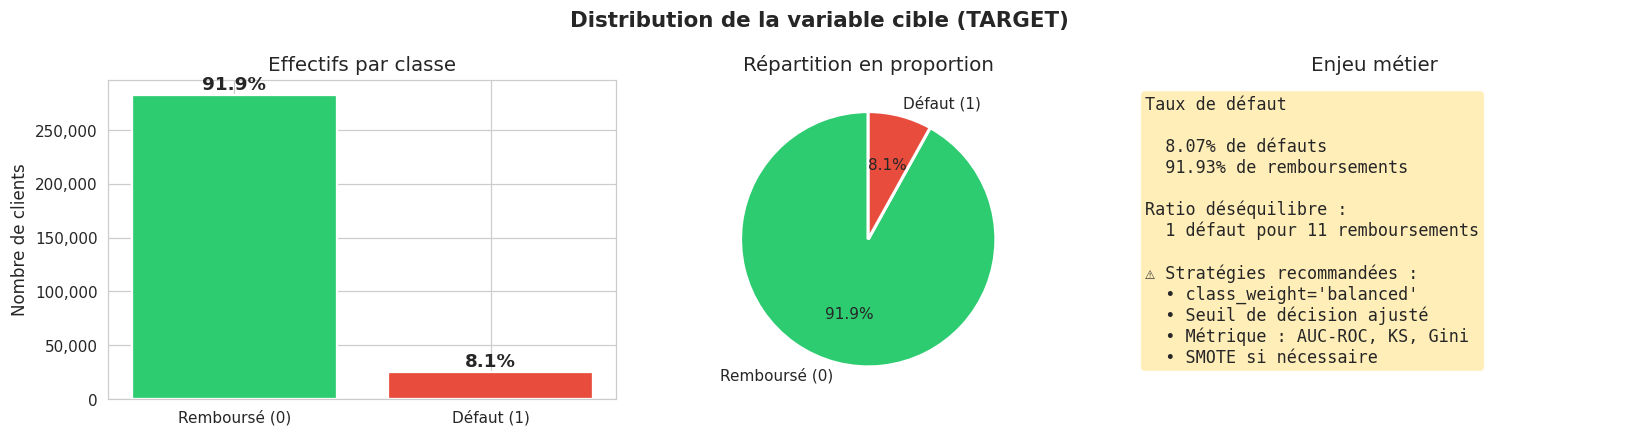


📊 Résumé TARGET :
   Total clients train : 307,511
   Défauts (1)         : 24,825 (8.07%)
   Remboursés (0)      : 282,686 (91.93%)


In [4]:
app = dfs["application_train"].copy()

target_counts = app["TARGET"].value_counts()
target_pct    = app["TARGET"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Distribution de la variable cible (TARGET)", fontsize=14, fontweight="bold")

# ── Barplot ──────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(["Remboursé (0)", "Défaut (1)"],
              target_counts.values,
              color=[C_OK, C_DEF], edgecolor="white", linewidth=1.5)
for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f"{pct:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=12)
ax.set_title("Effectifs par classe")
ax.set_ylabel("Nombre de clients")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# ── Pie chart ────────────────────────────────────────────────
ax = axes[1]
ax.pie(target_counts.values, labels=["Remboursé (0)", "Défaut (1)"],
       colors=[C_OK, C_DEF], autopct="%1.1f%%", startangle=90,
       wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Répartition en proportion")

# ── Annotation enjeu métier ───────────────────────────────────
ax = axes[2]
ax.axis("off")
taux_defaut = target_pct[1]
texte = (
    f"Taux de défaut\n\n"
    f"  {taux_defaut:.2f}% de défauts\n"
    f"  {target_pct[0]:.2f}% de remboursements\n\n"
    f"Ratio déséquilibre :\n"
    f"  1 défaut pour {target_counts[0]/target_counts[1]:.0f} remboursements\n\n"
    f"⚠ Stratégies recommandées :\n"
    f"  • class_weight='balanced'\n"
    f"  • Seuil de décision ajusté\n"
    f"  • Métrique : AUC-ROC, KS, Gini\n"
    f"  • SMOTE si nécessaire"
)
ax.text(0.05, 0.95, texte, transform=ax.transAxes, fontsize=11,
        verticalalignment="top", fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="#ffeaa7", alpha=0.8))
ax.set_title("Enjeu métier")

plt.tight_layout()
plt.show()

print(f"\n📊 Résumé TARGET :")
print(f"   Total clients train : {len(app):,}")
print(f"   Défauts (1)         : {target_counts[1]:,} ({taux_defaut:.2f}%)")
print(f"   Remboursés (0)      : {target_counts[0]:,} ({target_pct[0]:.2f}%)")


## 4. Qualité des données — Valeurs manquantes

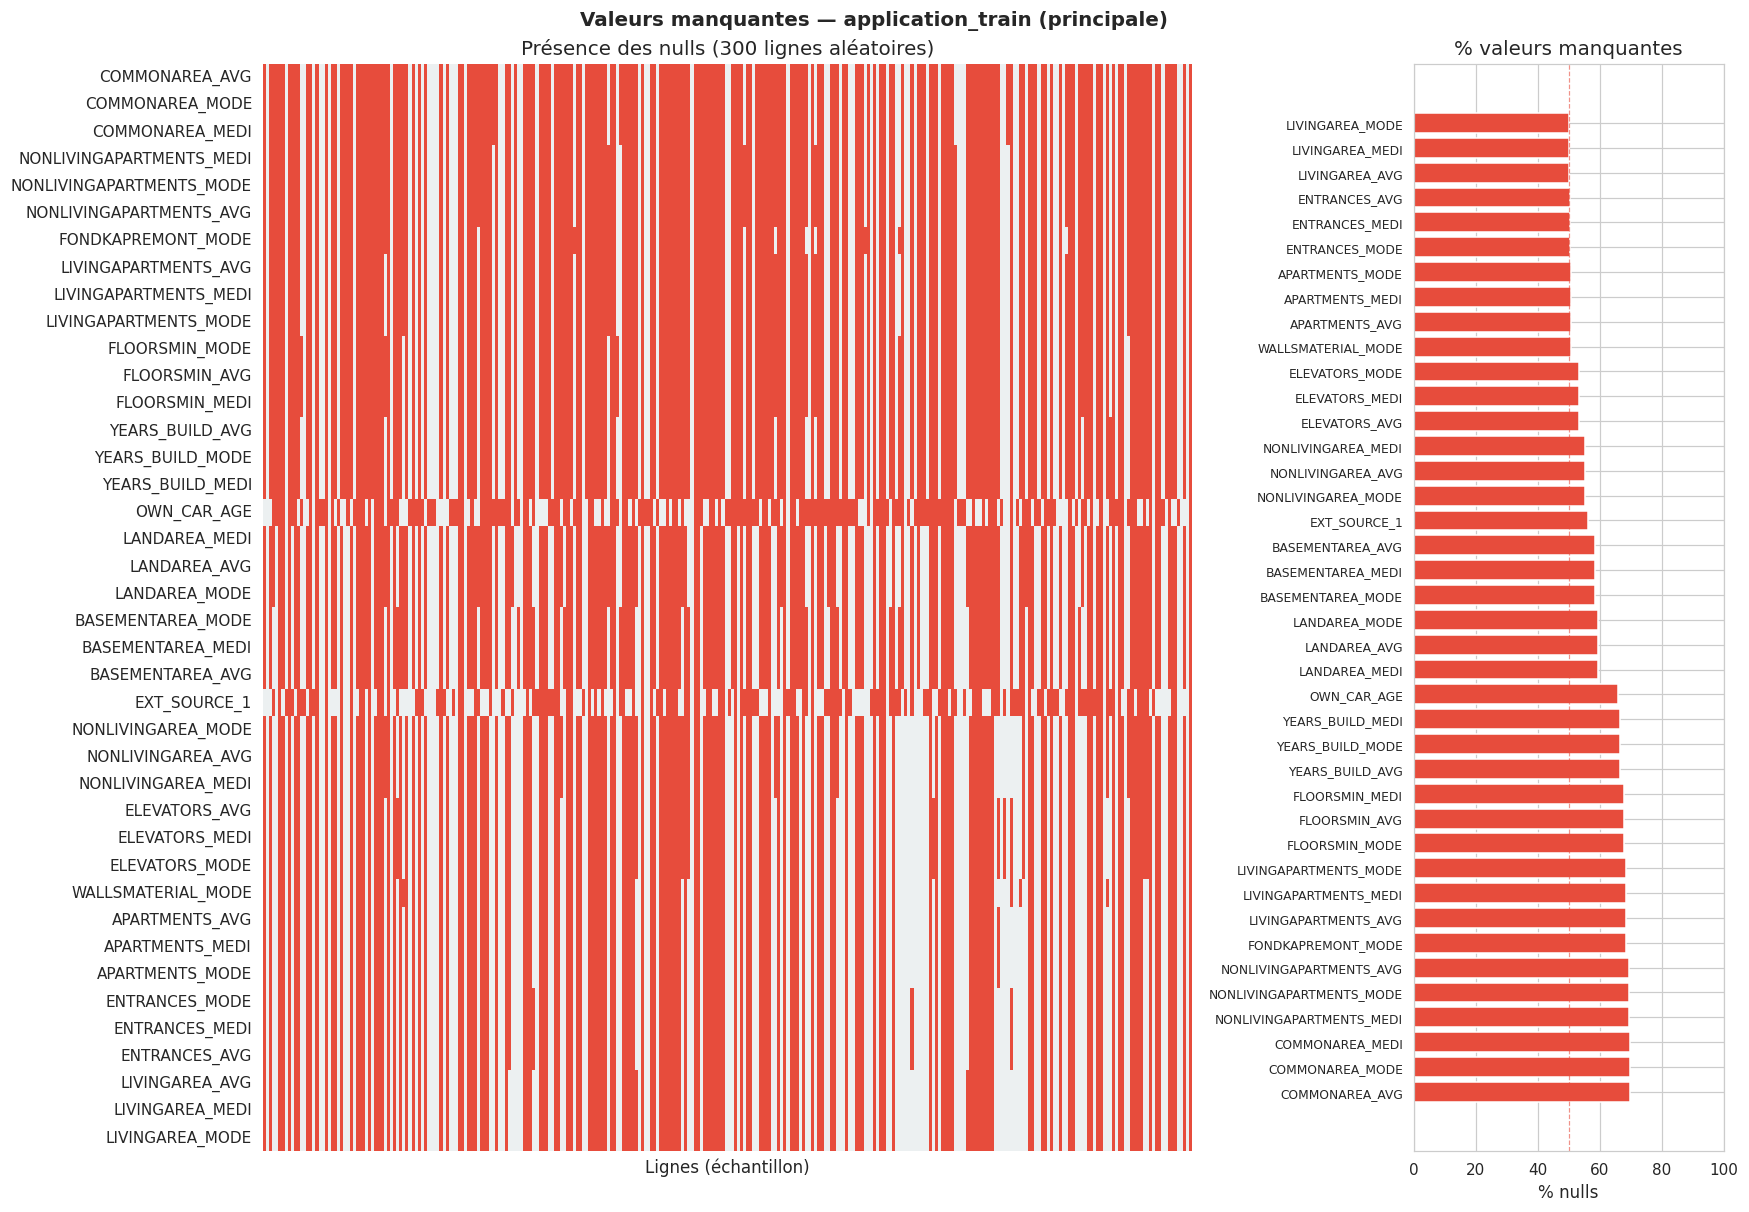

  → 40 colonnes avec des nulls
  → Colonnes > 50% nuls : 40


In [5]:
def heatmap_nulls(df, titre, top_n=40):
    """Heatmap missingno-style des colonnes les plus lacunaires."""
    pct_null = df.isnull().mean().sort_values(ascending=False)
    pct_null = pct_null[pct_null > 0].head(top_n)
    if pct_null.empty:
        print(f"  ✅ {titre} : aucune valeur manquante")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(pct_null)*0.28)),
                              gridspec_kw={"width_ratios": [3, 1]})
    fig.suptitle(f"Valeurs manquantes — {titre}", fontsize=13, fontweight="bold")

    # ── Heatmap par échantillon ──────────────────────────────
    sample = df[pct_null.index].sample(min(300, len(df)), random_state=42)
    mask   = sample.isnull()
    sns.heatmap(mask.T, cbar=False, yticklabels=True, xticklabels=False,
                cmap=["#ecf0f1", "#e74c3c"], ax=axes[0])
    axes[0].set_title("Présence des nulls (300 lignes aléatoires)")
    axes[0].set_xlabel("Lignes (échantillon)")

    # ── Barplot % nuls ───────────────────────────────────────
    colors = [C_DEF if v > 0.5 else C_BLUE if v > 0.2 else "#f39c12"
              for v in pct_null.values]
    axes[1].barh(range(len(pct_null)), pct_null.values * 100,
                 color=colors, edgecolor="white")
    axes[1].set_yticks(range(len(pct_null)))
    axes[1].set_yticklabels(pct_null.index, fontsize=8)
    axes[1].set_xlabel("% nulls")
    axes[1].set_xlim(0, 100)
    axes[1].axvline(50, color=C_DEF, linestyle="--", linewidth=0.8, alpha=0.6)
    axes[1].set_title("% valeurs manquantes")

    plt.tight_layout()
    plt.show()
    print(f"  → {len(pct_null)} colonnes avec des nulls")
    print(f"  → Colonnes > 50% nuls : {(pct_null > 0.5).sum()}")

heatmap_nulls(dfs["application_train"], "application_train (principale)")


In [6]:
# ── Tableau détaillé des nulls pour application_train ────────
pct_null = dfs["application_train"].isnull().mean() * 100
nb_null  = dfs["application_train"].isnull().sum()
tableau_null = pd.DataFrame({
    "Valeurs manquantes" : nb_null,
    "% manquant"         : pct_null.round(1),
    "Catégorie"          : pd.cut(pct_null,
                                  bins=[-1, 0, 5, 20, 50, 100],
                                  labels=["Complet", "< 5%", "5–20%", "20–50%", "> 50%"])
}).query("`% manquant` > 0").sort_values("% manquant", ascending=False)

print(f"Colonnes avec nulls : {len(tableau_null)}/{dfs['application_train'].shape[1]}")
print("\nRépartition par seuil :")
print(tableau_null["Catégorie"].value_counts().to_string())
print()
tableau_null.head(30)


Colonnes avec nulls : 64/122

Répartition par seuil :
Catégorie
> 50%      41
20–50%      9
5–20%       7
< 5%        7
Complet     0



,Valeurs manquantes,% manquant,Catégorie
COMMONAREA_AVG,214865,69.900,> 50%
COMMONAREA_MODE,214865,69.900,> 50%
COMMONAREA_MEDI,214865,69.900,> 50%
NONLIVINGAPARTMENTS_AVG,213514,69.400,> 50%
NONLIVINGAPARTMENTS_MODE,213514,69.400,> 50%
NONLIVINGAPARTMENTS_MEDI,213514,69.400,> 50%
LIVINGAPARTMENTS_AVG,210199,68.400,> 50%
LIVINGAPARTMENTS_MODE,210199,68.400,> 50%
LIVINGAPARTMENTS_MEDI,210199,68.400,> 50%
FONDKAPREMONT_MODE,210295,68.400,> 50%


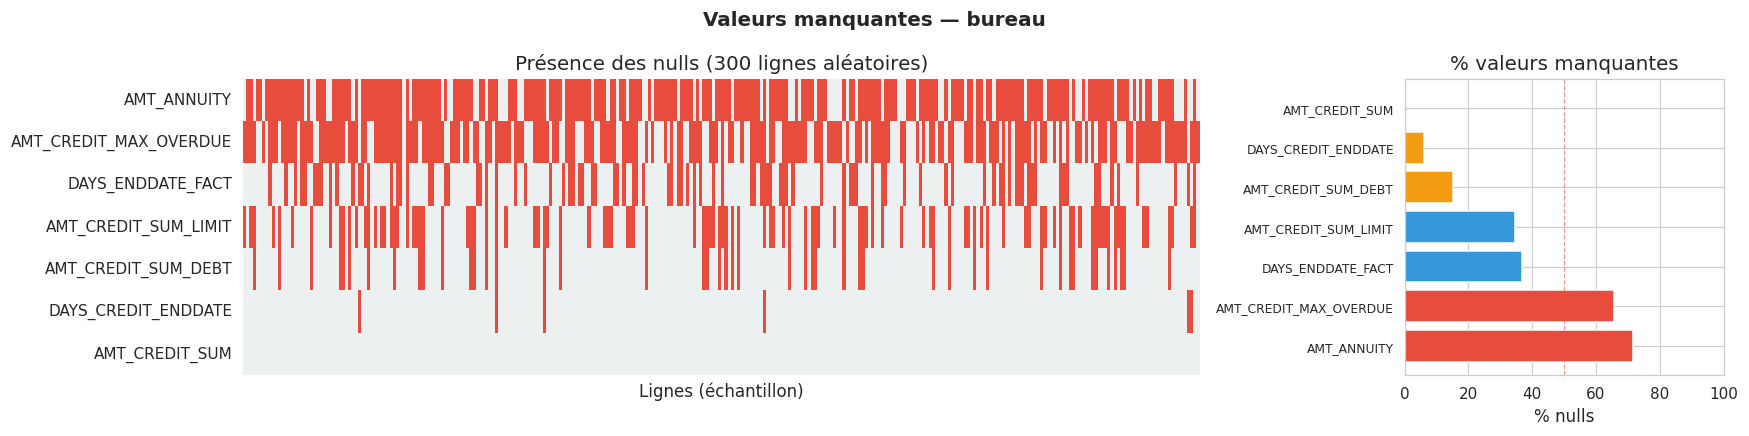

  → 7 colonnes avec des nulls
  → Colonnes > 50% nuls : 2


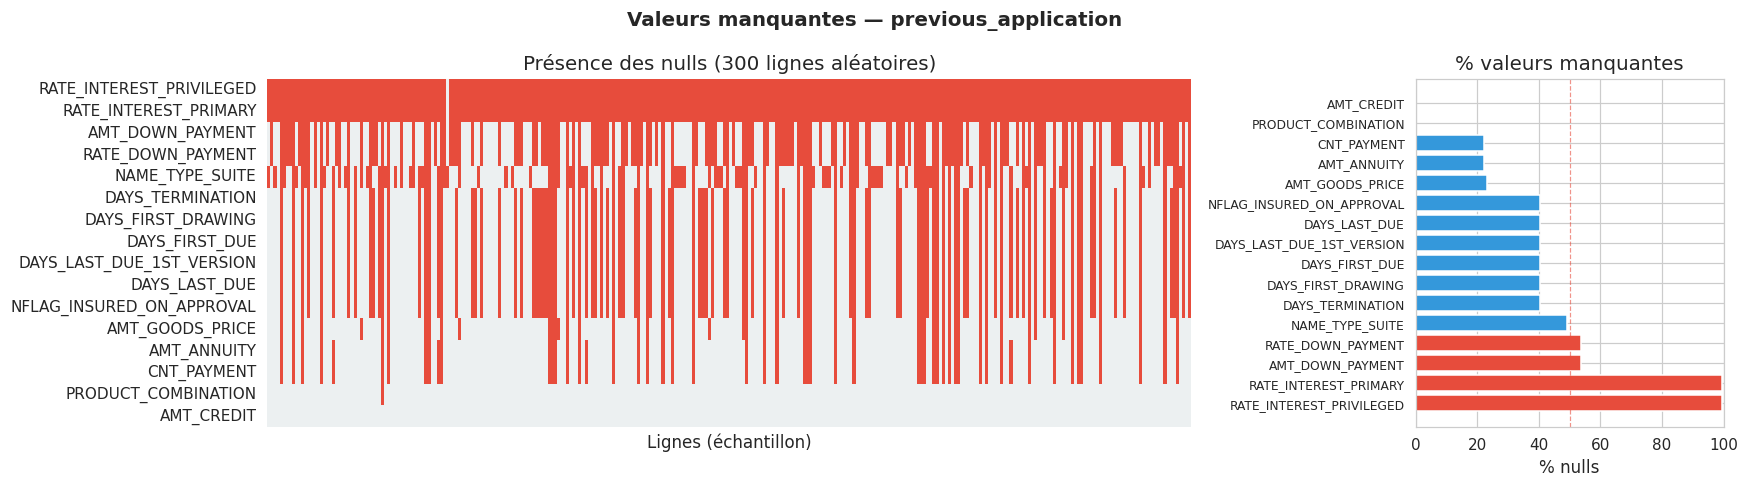

  → 16 colonnes avec des nulls
  → Colonnes > 50% nuls : 4


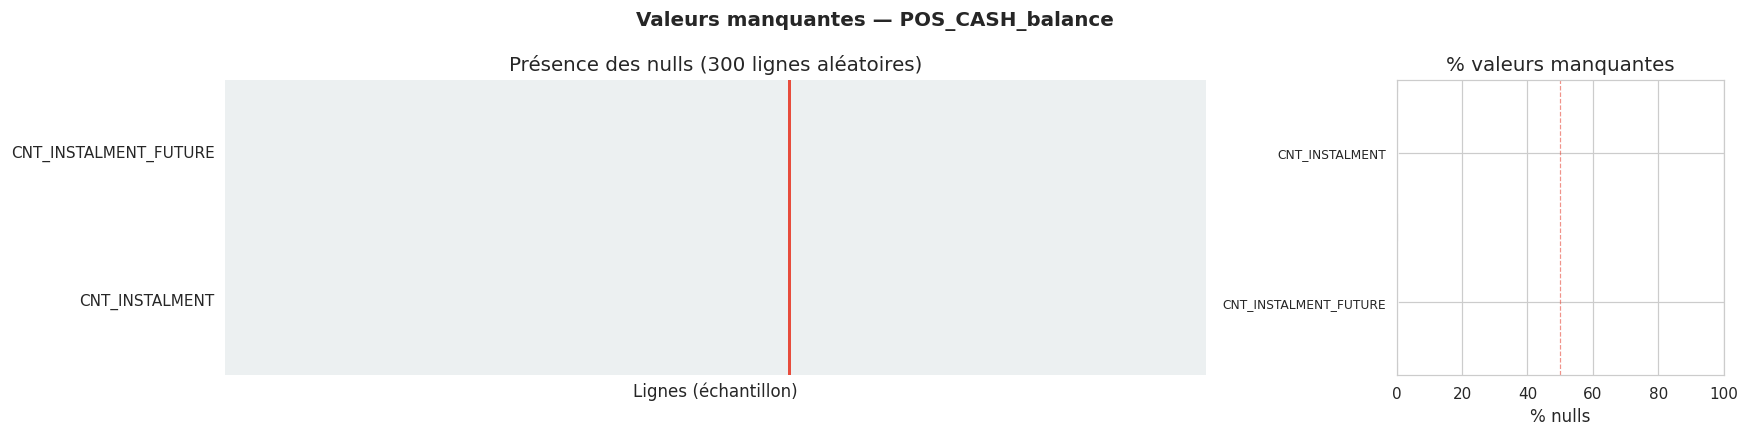

  → 2 colonnes avec des nulls
  → Colonnes > 50% nuls : 0


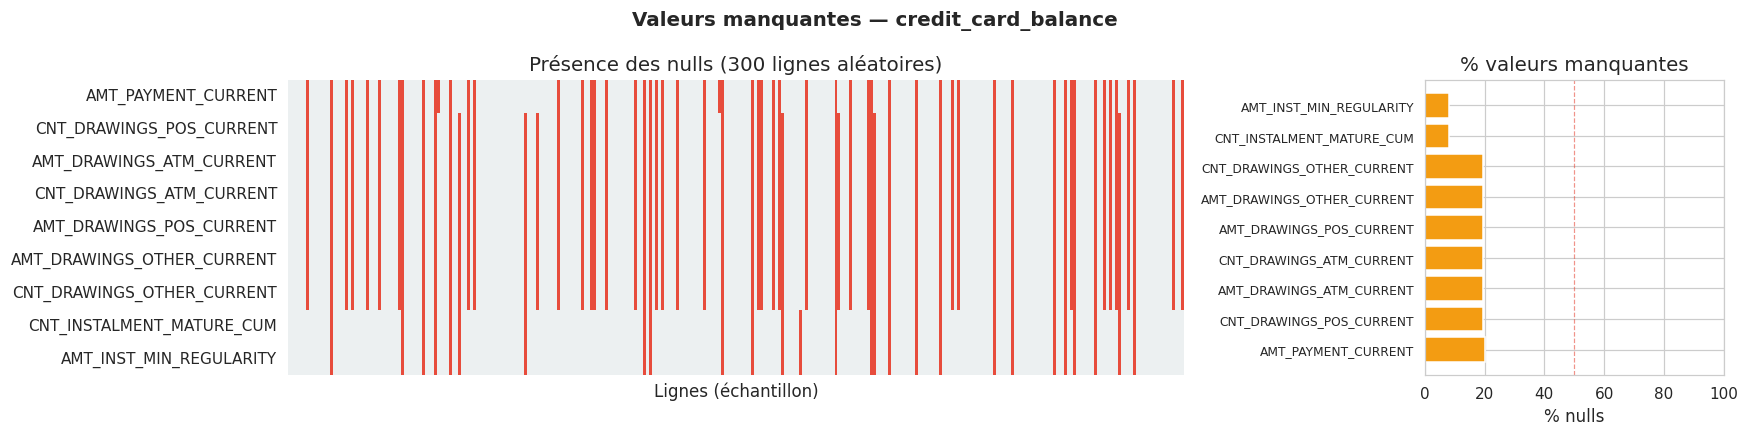

  → 9 colonnes avec des nulls
  → Colonnes > 50% nuls : 0


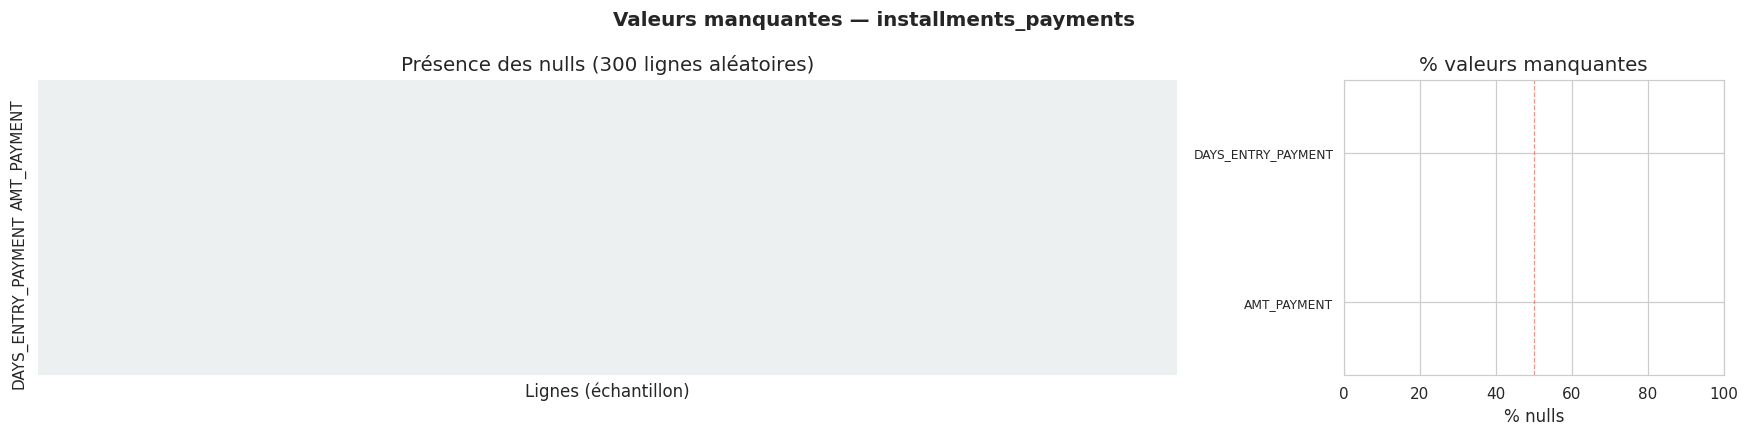

  → 2 colonnes avec des nulls
  → Colonnes > 50% nuls : 0


In [7]:
# ── Nulls pour les fichiers secondaires ──────────────────────
for nom in ["bureau", "previous_application", "POS_CASH_balance",
            "credit_card_balance", "installments_payments"]:
    if nom in dfs:
        heatmap_nulls(dfs[nom], nom, top_n=20)


## 5. Vérification des doublons

In [8]:
print("=" * 60)
print("VÉRIFICATION DES DOUBLONS")
print("=" * 60)

# ── Doublons complets ────────────────────────────────────────
for nom, df in dfs.items():
    dupl = df.duplicated().sum()
    statut = "⚠️ " if dupl > 0 else "✅"
    print(f"  {statut} {nom:<30} {dupl:>6,} doublons complets")

print()

# ── Unicité de SK_ID_CURR dans application_train ─────────────
app = dfs["application_train"]
nb_ids    = app["SK_ID_CURR"].nunique()
nb_lignes = len(app)
print(f"application_train — SK_ID_CURR unique : {nb_ids:,} / {nb_lignes:,} lignes")
if nb_ids == nb_lignes:
    print("  ✅ Clé primaire SK_ID_CURR est unique → 1 ligne par client")
else:
    print(f"  ⚠️  {nb_lignes - nb_ids} doublons sur SK_ID_CURR !")

# ── Chevauchement train/test ──────────────────────────────────
ids_train = set(dfs["application_train"]["SK_ID_CURR"])
ids_test  = set(dfs["application_test"]["SK_ID_CURR"])
overlap   = ids_train & ids_test
print(f"\nChevauchement train ∩ test : {len(overlap)} clients communs")
if len(overlap) == 0:
    print("  ✅ Train et test sont bien disjoints")
else:
    print("  ⚠️  Des clients apparaissent dans les deux jeux !")

# ── Cardinalité bureau / previous ────────────────────────────
print("\nNb lignes bureau par client (top 5) :")
print(dfs["bureau"].groupby("SK_ID_CURR").size()
      .describe(percentiles=[.25,.5,.75,.95,.99]).to_string())


VÉRIFICATION DES DOUBLONS
  ✅ application_train                   0 doublons complets
  ✅ application_test                    0 doublons complets
  ✅ bureau                              0 doublons complets
  ✅ bureau_balance                      0 doublons complets
  ✅ previous_application                0 doublons complets
  ✅ POS_CASH_balance                    0 doublons complets
  ✅ credit_card_balance                 0 doublons complets
  ✅ installments_payments               0 doublons complets

application_train — SK_ID_CURR unique : 307,511 / 307,511 lignes
  ✅ Clé primaire SK_ID_CURR est unique → 1 ligne par client

Chevauchement train ∩ test : 0 clients communs
  ✅ Train et test sont bien disjoints

Nb lignes bureau par client (top 5) :
count   305811.000
mean         5.613
std          4.430
min          1.000
25%          2.000
50%          4.000
75%          8.000
95%         14.000
99%         21.000
max        116.000


## 6. Application Train — Analyse par type de variable

### 6.1 Variables numériques clés


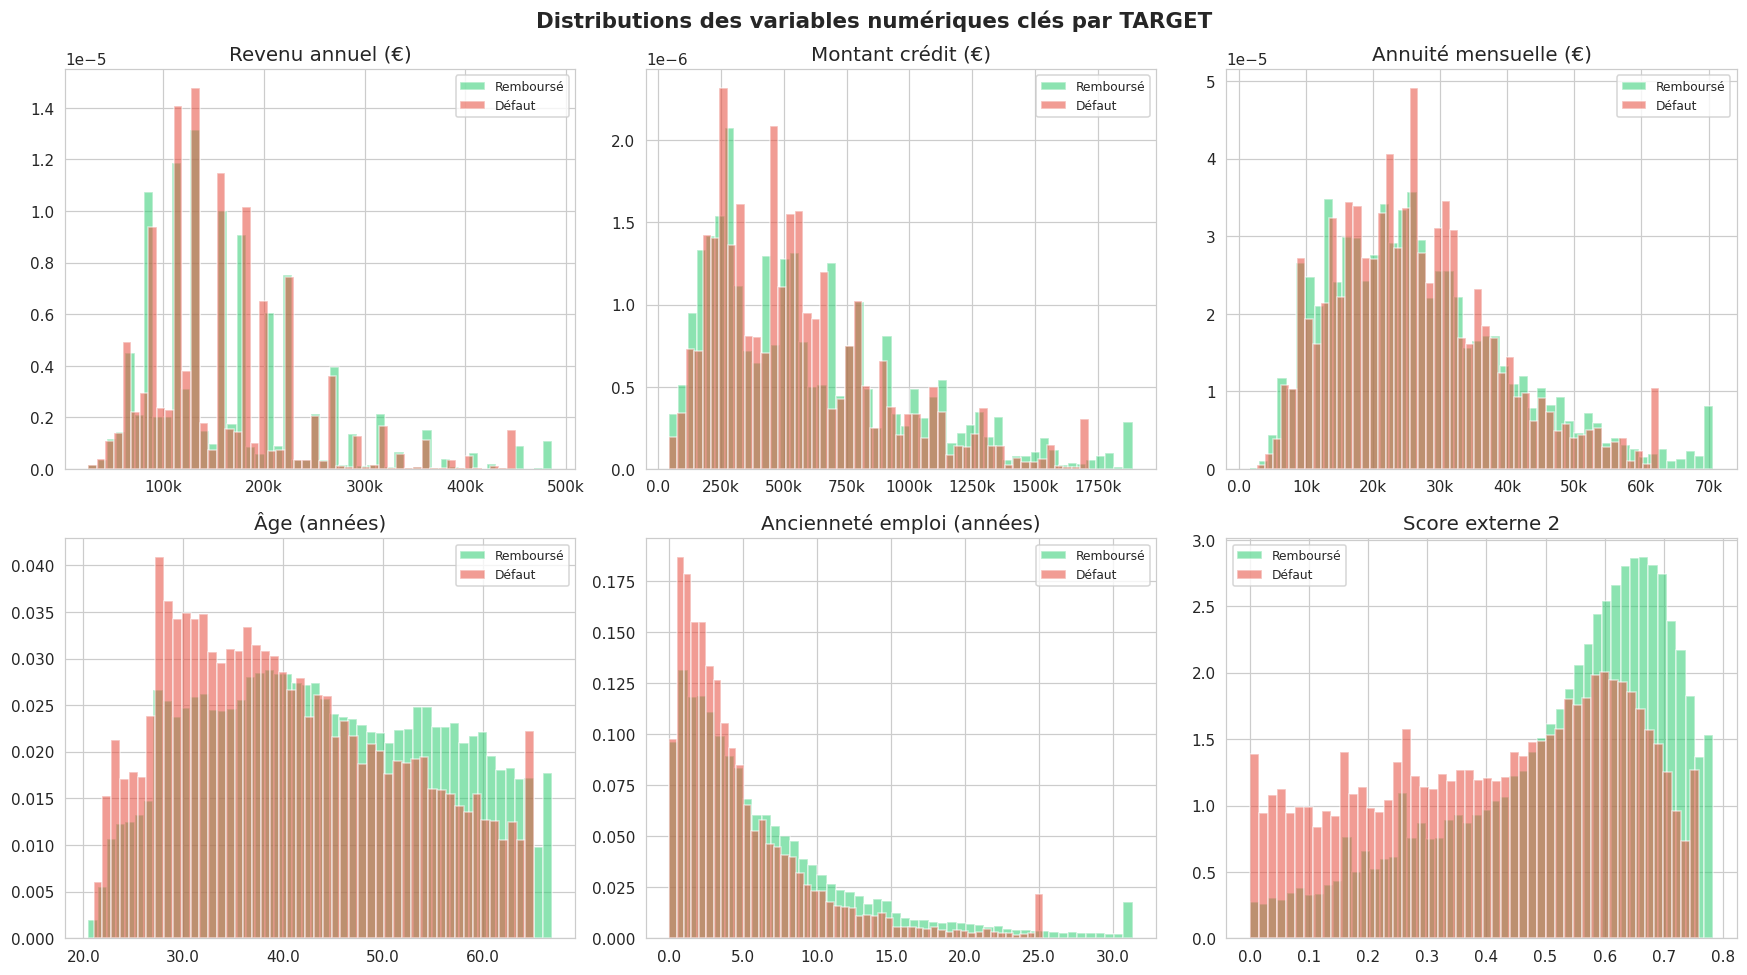

In [9]:
app = dfs["application_train"].copy()

# Variables numériques à explorer
num_cols = [
    ("AMT_INCOME_TOTAL",      "Revenu annuel"),
    ("AMT_CREDIT",            "Montant du crédit"),
    ("AMT_ANNUITY",           "Annuité mensuelle"),
    ("AMT_GOODS_PRICE",       "Prix du bien"),
    ("DAYS_BIRTH",            "Jours depuis naissance (négatif)"),
    ("DAYS_EMPLOYED",         "Jours depuis emploi (négatif)"),
    ("EXT_SOURCE_1",          "Score externe 1"),
    ("EXT_SOURCE_2",          "Score externe 2"),
    ("EXT_SOURCE_3",          "Score externe 3"),
]

# Convertir DAYS_BIRTH en âge positif
app["AGE_ANS"]     = -app["DAYS_BIRTH"] / 365.25
app["ANCIENNETE"]  = app["DAYS_EMPLOYED"].apply(lambda x: -x/365.25 if x < 0 else np.nan)

num_plot = [
    ("AMT_INCOME_TOTAL", "Revenu annuel (€)"),
    ("AMT_CREDIT",       "Montant crédit (€)"),
    ("AMT_ANNUITY",      "Annuité mensuelle (€)"),
    ("AGE_ANS",          "Âge (années)"),
    ("ANCIENNETE",       "Ancienneté emploi (années)"),
    ("EXT_SOURCE_2",     "Score externe 2"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distributions des variables numériques clés par TARGET",
             fontsize=14, fontweight="bold")

for ax, (col, label) in zip(axes.flat, num_plot):
    data = app[["TARGET", col]].dropna()
    for tgt, color, lbl in [(0, C_OK, "Remboursé"), (1, C_DEF, "Défaut")]:
        subset = data[data["TARGET"] == tgt][col]
        # Cap à 99e percentile pour la lisibilité
        cap = subset.quantile(0.99)
        subset = subset.clip(upper=cap)
        ax.hist(subset, bins=50, alpha=0.55, color=color, label=lbl, density=True)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1e3:.0f}k" if x >= 1000 else f"{x:.1f}"))

plt.tight_layout()
plt.show()


### 6.2 Taux de défaut par variable catégorielle

In [ ]:
def plot_taux_defaut_cat(df, col, titre, max_cat=15):
    """Barplot du taux de défaut par modalité d'une variable catégorielle."""
    stats = (df.groupby(col)["TARGET"]
               .agg(["mean", "count"])
               .rename(columns={"mean": "taux_defaut", "count": "effectif"})
               .sort_values("taux_defaut", ascending=False)
               .head(max_cat)
               .reset_index())

    fig, ax1 = plt.subplots(figsize=(10, 4))
    colors = [C_DEF if t > df["TARGET"].mean() else C_BLUE
              for t in stats["taux_defaut"]]
    bars = ax1.bar(stats[col].astype(str), stats["taux_defaut"] * 100,
                   color=colors, edgecolor="white")
    ax1.axhline(df["TARGET"].mean() * 100, color="orange", linestyle="--",
                linewidth=1.5, label=f"Moyenne ({df['TARGET'].mean()*100:.1f}%)")
    ax1.set_ylabel("Taux de défaut (%)")
    ax1.set_title(f"Taux de défaut par {titre}")
    ax1.legend()
    plt.xticks(rotation=35, ha="right", fontsize=9)

    # Effectifs en annotation
    for bar, n in zip(bars, stats["effectif"]):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f"n={n:,}", ha="center", va="bottom", fontsize=7, rotation=0)

    plt.tight_layout()
    plt.show()

cat_cols = [
    ("NAME_CONTRACT_TYPE",   "Type de contrat"),
    ("CODE_GENDER",          "Genre"),
    ("NAME_INCOME_TYPE",     "Type de revenu"),
    ("NAME_EDUCATION_TYPE",  "Niveau d'éducation"),
    ("NAME_FAMILY_STATUS",   "Statut familial"),
    ("NAME_HOUSING_TYPE",    "Type de logement"),
    ("OCCUPATION_TYPE",      "Profession"),
]
for col, titre in cat_cols:
    if col in app.columns:
        plot_taux_defaut_cat(app, col, titre)


### 6.3 Anomalie DAYS_EMPLOYED (valeur 365 243)

In [ ]:
# 365 243 jours ≈ 1000 ans → valeur sentinelle pour 'non employé'
anomalie = (app["DAYS_EMPLOYED"] == 365243).sum()
print(f"Valeur anomalie DAYS_EMPLOYED = 365243 : {anomalie:,} clients ({anomalie/len(app)*100:.1f}%)")

# Taux de défaut avec vs sans anomalie
taux_avec    = app[app["DAYS_EMPLOYED"] == 365243]["TARGET"].mean() * 100
taux_sans    = app[app["DAYS_EMPLOYED"] != 365243]["TARGET"].mean() * 100
taux_global  = app["TARGET"].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ["Non employé\n(DAYS=365243)", "Employé\n(valeur normale)", "Global"],
    [taux_avec, taux_sans, taux_global],
    color=[C_DEF, C_OK, C_BLUE], edgecolor="white", width=0.5
)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Taux de défaut (%)")
ax.set_title("Impact de l'anomalie DAYS_EMPLOYED sur le taux de défaut")
ax.set_ylim(0, taux_avec * 1.3)
plt.tight_layout()
plt.show()

print(f"\n→ Les clients 'non employés' ont un taux de défaut {taux_avec/taux_sans:.1f}x plus élevé")
print("→ Cette anomalie est traitée : DAYS_EMPLOYED → NULL + flag FE_EMPLOYED_ANOMALY")


### 6.4 Scores externes — Meilleurs prédicteurs

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("EXT_SOURCE 1/2/3 — Distribution par TARGET (meilleurs prédicteurs)",
             fontsize=13, fontweight="bold")

for ax, col in zip(axes, ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]):
    for tgt, color, lbl in [(0, C_OK, "Remboursé"), (1, C_DEF, "Défaut")]:
        data = app[app["TARGET"] == tgt][col].dropna()
        ax.hist(data, bins=40, alpha=0.6, color=color, label=lbl, density=True)

        # Ligne médiane
        ax.axvline(data.median(), color=color, linestyle="--", linewidth=1.5)

    ax.set_title(col)
    ax.set_xlabel("Score (0 → mauvais, 1 → bon)")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Corrélation avec TARGET
print("Corrélation avec TARGET (Pearson) :")
for col in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]:
    corr = app[col].corr(app["TARGET"])
    print(f"  {col} : {corr:.4f}  ({'négatif fort → bon prédicteur' if corr < -0.2 else ''})")


## 7. Fichiers secondaires — Analyse par source

In [ ]:
print("=" * 65)
print("BUREAU — Historique crédits externes")
print("=" * 65)

bur = dfs["bureau"]
print(f"Lignes : {len(bur):,}  |  Colonnes : {bur.shape[1]}")
print(f"Clients uniques : {bur['SK_ID_CURR'].nunique():,}")
print(f"Crédits par client (médiane) : {bur.groupby('SK_ID_CURR').size().median():.0f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Bureau — Crédits externes", fontweight="bold")

# Nombre de crédits par client
nb_cred = bur.groupby("SK_ID_CURR").size()
axes[0].hist(nb_cred.clip(upper=nb_cred.quantile(0.99)), bins=40,
             color=C_BLUE, edgecolor="white")
axes[0].set_title("Nb crédits bureau / client")
axes[0].set_xlabel("Nombre de crédits")

# Statut crédit
statut_pct = bur["CREDIT_ACTIVE"].value_counts(normalize=True) * 100
axes[1].bar(statut_pct.index, statut_pct.values,
            color=[C_OK, C_DEF, C_BLUE, "#f39c12"][:len(statut_pct)],
            edgecolor="white")
axes[1].set_title("Statut crédit bureau")
axes[1].set_ylabel("%")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20, ha="right")

# Jours en retard (overdue)
overdue = bur[bur["CREDIT_DAY_OVERDUE"] > 0]["CREDIT_DAY_OVERDUE"]
axes[2].hist(overdue.clip(upper=overdue.quantile(0.99)), bins=40,
             color=C_DEF, edgecolor="white")
axes[2].set_title(f"Jours en retard (parmi {len(overdue):,} crédits)")
axes[2].set_xlabel("Jours overdue")

plt.tight_layout()
plt.show()


In [ ]:
print("=" * 65)
print("BUREAU BALANCE — Statut mensuel")
print("=" * 65)

bb = dfs["bureau_balance"]
print(f"Lignes : {len(bb):,}  |  Crédits bureau uniques : {bb['SK_ID_BUREAU'].nunique():,}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Bureau Balance — Statut mensuel des crédits", fontweight="bold")

statut_bb = bb["STATUS"].value_counts()
axes[0].bar(statut_bb.index, statut_bb.values,
            color=C_BLUE, edgecolor="white")
axes[0].set_title("Distribution des statuts")
axes[0].set_ylabel("Occurrences")
# Légende statuts
legend_txt = ("C=Closed, 0=à jour, 1=1-29j retard\n"
              "2=30-59j, 3=60-89j, 4=90-119j\n"
              "5=120+j retard, X=Inconnu")
axes[0].text(0.98, 0.97, legend_txt, transform=axes[0].transAxes,
             fontsize=8, va="top", ha="right",
             bbox=dict(boxstyle="round", facecolor="#ffeaa7", alpha=0.7))

# Distribution temporelle
axes[1].hist(bb["MONTHS_BALANCE"], bins=50, color=C_BLUE, edgecolor="white")
axes[1].set_title("Distribution des mois de solde")
axes[1].set_xlabel("MONTHS_BALANCE (0 = mois courant, -96 = 8 ans)")
axes[1].axvline(bb["MONTHS_BALANCE"].median(), color="orange",
                linestyle="--", label=f"Médiane : {bb['MONTHS_BALANCE'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
print("=" * 65)
print("PREVIOUS APPLICATION — Demandes précédentes")
print("=" * 65)

prev = dfs["previous_application"]
print(f"Lignes : {len(prev):,}  |  Clients : {prev['SK_ID_CURR'].nunique():,}")
print(f"Demandes précédentes / client (médiane) : "
      f"{prev.groupby('SK_ID_CURR').size().median():.0f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Demandes Précédentes", fontweight="bold")

# Statut des contrats
stat = prev["NAME_CONTRACT_STATUS"].value_counts()
axes[0,0].bar(stat.index, stat.values,
              color=[C_OK, C_DEF, "#f39c12", C_BLUE][:len(stat)],
              edgecolor="white")
axes[0,0].set_title("Statut des demandes précédentes")
axes[0,0].set_ylabel("Nb demandes")
plt.setp(axes[0,0].xaxis.get_majorticklabels(), rotation=20, ha="right")

# Type de contrat
type_ct = prev["NAME_CONTRACT_TYPE"].value_counts()
axes[0,1].pie(type_ct.values, labels=type_ct.index, autopct="%1.1f%%",
              colors=[C_BLUE, C_OK, C_DEF, "#f39c12"][:len(type_ct)],
              wedgeprops={"edgecolor": "white"})
axes[0,1].set_title("Type de contrat")

# Nb demandes précédentes par client
nb_prev = prev.groupby("SK_ID_CURR").size()
axes[1,0].hist(nb_prev.clip(upper=nb_prev.quantile(0.99)), bins=40,
               color=C_BLUE, edgecolor="white")
axes[1,0].set_title("Nb demandes précédentes / client")
axes[1,0].set_xlabel("Nombre de demandes")

# Taux refus (joint avec train)
refus = prev.groupby("SK_ID_CURR")["NAME_CONTRACT_STATUS"].apply(
    lambda x: (x == "Refused").mean()
).reset_index(name="taux_refus")
merged = dfs["application_train"][["SK_ID_CURR","TARGET"]].merge(refus, on="SK_ID_CURR")
bins = [0, 0.1, 0.3, 0.5, 0.7, 1.01]
labels_b = ["0–10%", "10–30%", "30–50%", "50–70%", "70–100%"]
merged["groupe_refus"] = pd.cut(merged["taux_refus"], bins=bins, labels=labels_b)
taux_def_refus = merged.groupby("groupe_refus")["TARGET"].mean() * 100
axes[1,1].bar(taux_def_refus.index.astype(str), taux_def_refus.values,
              color=[C_BLUE, "#f39c12", "#e67e22", "#e74c3c", "#c0392b"],
              edgecolor="white")
axes[1,1].axhline(dfs["application_train"]["TARGET"].mean()*100,
                  color="gray", linestyle="--", label="Taux global")
axes[1,1].set_title("Taux de défaut vs taux de refus historique")
axes[1,1].set_ylabel("Taux de défaut (%)")
axes[1,1].set_xlabel("Taux de refus passé")
axes[1,1].legend()

plt.tight_layout()
plt.show()


In [ ]:
print("=" * 65)
print("POS CASH BALANCE — Soldes mensuels POS & cash")
print("=" * 65)

pos = dfs["POS_CASH_balance"]
print(f"Lignes : {len(pos):,}  |  Clients : {pos['SK_ID_CURR'].nunique():,}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("POS Cash Balance", fontweight="bold")

# DPD distribution
dpd = pos["SK_DPD"].clip(upper=pos["SK_DPD"].quantile(0.99))
axes[0].hist(dpd, bins=50, color=C_BLUE, edgecolor="white", log=True)
axes[0].set_title("SK_DPD — Jours de retard (log)")
axes[0].set_xlabel("Jours de retard")
pct_dpd = (pos["SK_DPD"] > 0).mean() * 100
axes[0].text(0.65, 0.9, f"{pct_dpd:.1f}% retards",
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(facecolor="#ffeaa7", alpha=0.7))

# Statut contrat
st = pos["NAME_CONTRACT_STATUS"].value_counts().head(6)
axes[1].barh(st.index, st.values, color=C_BLUE, edgecolor="white")
axes[1].set_title("Statut contrat (top 6)")

# Nb enregistrements par client
nb = pos.groupby("SK_ID_CURR").size()
axes[2].hist(nb.clip(upper=nb.quantile(0.99)), bins=40, color=C_BLUE, edgecolor="white")
axes[2].set_title("Nb enregistrements / client")

plt.tight_layout()
plt.show()


In [ ]:
print("=" * 65)
print("CREDIT CARD BALANCE — Carte de crédit")
print("=" * 65)

cc = dfs["credit_card_balance"]
print(f"Lignes : {len(cc):,}  |  Clients : {cc['SK_ID_CURR'].nunique():,}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Credit Card Balance", fontweight="bold")

# Solde carte
bal = cc["AMT_BALANCE"].clip(lower=cc["AMT_BALANCE"].quantile(0.01),
                              upper=cc["AMT_BALANCE"].quantile(0.99))
axes[0].hist(bal, bins=50, color=C_BLUE, edgecolor="white")
axes[0].set_title("Solde moyen carte (€)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e3:.0f}k"))

# Taux d'utilisation
cc["utilisation"] = cc["AMT_BALANCE"] / cc["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan)
util = cc["utilisation"].clip(0, 2).dropna()
axes[1].hist(util, bins=50, color=C_BLUE, edgecolor="white")
axes[1].axvline(1, color=C_DEF, linestyle="--", label="Limite atteinte")
axes[1].set_title("Taux utilisation carte (solde/limite)")
axes[1].legend()

# DPD
dpd_cc = cc["SK_DPD"].clip(upper=cc["SK_DPD"].quantile(0.99))
axes[2].hist(dpd_cc, bins=50, color=C_BLUE, edgecolor="white", log=True)
pct_dpd = (cc["SK_DPD"] > 0).mean() * 100
axes[2].set_title(f"SK_DPD carte (log) — {pct_dpd:.1f}% retards")
axes[2].set_xlabel("Jours de retard")

plt.tight_layout()
plt.show()


In [ ]:
print("=" * 65)
print("INSTALLMENTS PAYMENTS — Paiements d'échéances")
print("=" * 65)

inst = dfs["installments_payments"]
print(f"Lignes : {len(inst):,}  |  Clients : {inst['SK_ID_CURR'].nunique():,}")

inst["payment_delay"] = inst["DAYS_ENTRY_PAYMENT"] - inst["DAYS_INSTALMENT"]
inst["payment_ratio"] = inst["AMT_PAYMENT"] / inst["AMT_INSTALMENT"].replace(0, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Installments Payments", fontweight="bold")

# Retard de paiement
delay = inst["payment_delay"].clip(-30, 60)
axes[0].hist(delay, bins=60, color=C_BLUE, edgecolor="white")
axes[0].axvline(0, color=C_DEF, linestyle="--", linewidth=1.5, label="Échéance")
pct_late = (inst["payment_delay"] > 0).mean() * 100
axes[0].set_title(f"Retard de paiement (jours) — {pct_late:.1f}% en retard")
axes[0].set_xlabel("Jours (positif = retard)")
axes[0].legend()

# Ratio paiement
ratio = inst["payment_ratio"].clip(0, 2).dropna()
axes[1].hist(ratio, bins=50, color=C_BLUE, edgecolor="white")
axes[1].axvline(1, color=C_DEF, linestyle="--", label="Paiement exact")
pct_sous = (inst["payment_ratio"] < 0.95).mean() * 100
axes[1].set_title(f"Ratio payé/dû — {pct_sous:.1f}% sous-paiements")
axes[1].legend()

# Retard moyen par client → corrélation TARGET
delay_client = inst.groupby("SK_ID_CURR")["payment_delay"].mean().reset_index(
    name="retard_moyen")
merged = dfs["application_train"][["SK_ID_CURR","TARGET"]].merge(
    delay_client, on="SK_ID_CURR")
bins  = [-31, 0, 3, 10, 30, 200]
lbls  = ["À l'avance", "0-3j", "3-10j", "10-30j", ">30j"]
merged["grp"] = pd.cut(merged["retard_moyen"], bins=bins, labels=lbls)
td = merged.groupby("grp")["TARGET"].mean() * 100
axes[2].bar(td.index.astype(str), td.values,
            color=[C_OK, C_BLUE, "#f39c12", "#e67e22", C_DEF],
            edgecolor="white")
axes[2].axhline(dfs["application_train"]["TARGET"].mean()*100,
                color="gray", linestyle="--")
axes[2].set_title("Taux de défaut vs retard moyen")
axes[2].set_ylabel("Taux de défaut (%)")

plt.tight_layout()
plt.show()


## 8. Matrice de corrélations — Variables numériques clés

In [ ]:
app = dfs["application_train"].copy()
app["AGE_ANS"]    = -app["DAYS_BIRTH"] / 365.25
app["ANCIENNETE"] = app["DAYS_EMPLOYED"].apply(lambda x: -x/365.25 if x < 0 else np.nan)

cols_corr = [
    "TARGET", "AMT_CREDIT", "AMT_INCOME_TOTAL", "AMT_ANNUITY",
    "AMT_GOODS_PRICE", "AGE_ANS", "ANCIENNETE",
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
    "REGION_POPULATION_RELATIVE", "CNT_CHILDREN", "CNT_FAM_MEMBERS",
    "OBS_30_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE",
]
corr_mat = app[cols_corr].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1,
            annot_kws={"size": 7.5}, linewidths=0.5,
            ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Matrice de corrélations — Application Train", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Top corrélations avec TARGET
print("\nTop corrélations avec TARGET :")
corr_target = corr_mat["TARGET"].drop("TARGET").sort_values()
print("  Corrélations négatives (protecteurs) :")
print(corr_target.head(5).to_string())
print("  Corrélations positives (risque) :")
print(corr_target.tail(5).to_string())


## 9. Vues SQL PostgreSQL

Cette section se connecte à PostgreSQL pour explorer les vues construites par le pipeline.
Exécuter d'abord `phase1_1_inject_raw.py` puis `phase1_2_views_fe_enum.py`.


In [ ]:
try:
    from src.database import get_engine
    engine = get_engine()
    with engine.connect() as conn:
        conn.execute(__import__("sqlalchemy").text("SELECT 1"))
    DB_OK = True
    print(f"✅ Connexion PostgreSQL OK : {engine.url.host}/{engine.url.database}")
except Exception as e:
    DB_OK = False
    print(f"⚠️  PostgreSQL non disponible : {e}")
    print("   Lancez d'abord les pipelines phase1_1 et phase1_2")


In [ ]:
if DB_OK:
    # ── Inventaire des vues disponibles ───────────────────────
    from sqlalchemy import text
    with engine.connect() as conn:
        vues = pd.read_sql(
            text("SELECT table_name FROM information_schema.views "
                 "WHERE table_schema = 'public' ORDER BY table_name"),
            conn
        )
    print("Vues disponibles dans PostgreSQL :")
    for v in vues["table_name"]:
        print(f"  • {v}")


In [ ]:
if DB_OK:
    # ── Chargement v_features_engineering ─────────────────────
    with engine.connect() as conn:
        df_fe = pd.read_sql(
            text("SELECT * FROM v_features_engineering WHERE split = 'train' LIMIT 50000"),
            conn
        )
    print(f"v_features_engineering (train, 50k) : {df_fe.shape}")

    # Colonnes FE
    fe_cols = [c for c in df_fe.columns if c.startswith("fe_")]
    print(f"\nFeatures engineerées SQL ({len(fe_cols)}) :")
    for c in fe_cols:
        non_null = df_fe[c].notna().mean() * 100
        print(f"  {c:<35} {non_null:>5.1f}% non-nuls")


In [ ]:
if DB_OK and "df_fe" in dir():
    fe_cols_plot = [c for c in fe_cols if df_fe[c].notna().sum() > 1000]

    n = len(fe_cols_plot)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
    fig.suptitle("Distributions des features engineerées SQL par TARGET",
                 fontsize=13, fontweight="bold")
    axes_flat = axes.flat if nrows > 1 else [axes] if ncols == 1 else axes.flat

    for ax, col in zip(axes_flat, fe_cols_plot):
        data = df_fe[["TARGET", col]].dropna()
        for tgt, color, lbl in [(0, C_OK, "Remboursé"), (1, C_DEF, "Défaut")]:
            subset = data[data["TARGET"] == tgt][col]
            cap = subset.quantile(0.99)
            subset = subset.clip(upper=cap)
            ax.hist(subset, bins=40, alpha=0.55, color=color, label=lbl, density=True)
        ax.set_title(col.replace("fe_", ""), fontsize=9)
        ax.legend(fontsize=7)

    # Masquer les axes vides
    for ax in list(axes_flat)[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()


In [ ]:
if DB_OK and "df_fe" in dir():
    # ── Corrélations features engineerées avec TARGET ──────────
    corrs_fe = df_fe[fe_cols + ["TARGET"]].corr()["TARGET"].drop("TARGET")
    corrs_fe = corrs_fe.sort_values()

    fig, ax = plt.subplots(figsize=(9, 5))
    colors = [C_DEF if v > 0 else C_OK for v in corrs_fe.values]
    ax.barh(corrs_fe.index, corrs_fe.values, color=colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("Corrélation features engineerées vs TARGET", fontweight="bold")
    ax.set_xlabel("Corrélation de Pearson")
    plt.tight_layout()
    plt.show()

    print("\nCorrélations features SQL vs TARGET :")
    print(corrs_fe.to_string())


In [ ]:
if DB_OK:
    # ── Vérification intégrité v_master ────────────────────────
    with engine.connect() as conn:
        nb_master = pd.read_sql(
            text("SELECT split, COUNT(*) as nb FROM v_master GROUP BY split"),
            conn
        )
    print("Intégrité v_master :")
    print(nb_master.to_string(index=False))

    # ── Nulls dans les colonnes de jointure (coverage tables secondaires)
    with engine.connect() as conn:
        df_cov = pd.read_sql(
            text("""SELECT
                COUNT(*) as total,
                COUNT(bureau_credit_count)    as avec_bureau,
                COUNT(prev_app_count)         as avec_previous,
                COUNT(pos_records_count)      as avec_pos,
                COUNT(cc_records_count)       as avec_cc,
                COUNT(install_records_count)  as avec_installments
            FROM v_master WHERE split = 'train'"""),
            conn
        )
    total = df_cov["total"].iloc[0]
    print("\nCouverture des tables secondaires (% clients avec données) :")
    for col in df_cov.columns[1:]:
        n = df_cov[col].iloc[0]
        print(f"  {col.replace('avec_', ''):<20} {n:>7,} / {total:,}  ({n/total*100:.1f}%)")


## 10. Synthèse & recommandations pour la modélisation

In [ ]:
print("=" * 70)
print("SYNTHÈSE EDA — POINTS CLÉS POUR LA MODÉLISATION")
print("=" * 70)

app = dfs["application_train"]
taux_def = app["TARGET"].mean() * 100

print(f"""
📊 VARIABLE CIBLE
   Taux de défaut       : {taux_def:.2f}%
   Déséquilibre         : 1 défaut pour {app['TARGET'].eq(0).sum()//app['TARGET'].sum():.0f} remboursements
   Recommandation       : class_weight='balanced' ou SMOTE, seuil métier ajusté
   Métrique principale  : AUC-ROC + KS Statistic + Gini

📋 QUALITÉ DES DONNÉES
   Colonnes > 50% nuls  : {(app.isnull().mean() > 0.5).sum()} (immobilier, EXT_SOURCE_1)
   Anomalie DAYS_EMPLOYED: 365243 → {(app.DAYS_EMPLOYED==365243).sum():,} clients ({(app.DAYS_EMPLOYED==365243).mean()*100:.1f}%)
   Doublons             : {app.duplicated().sum()} (SK_ID_CURR unique ✅)

🔑 MEILLEURS PRÉDICTEURS (corrélation avec TARGET)
   EXT_SOURCE_2         : prédicteur négatif fort (crédit bureau externe)
   EXT_SOURCE_3         : prédicteur négatif fort
   EXT_SOURCE_1         : prédicteur négatif modéré (56% nuls !)
   DEF_30_CNT_SOCIAL    : prédicteur positif (défauts entourage)
   AGE (DAYS_BIRTH)     : les jeunes = plus de défauts

⚙️ FEATURES ENGINEERÉES SQL
   fe_credit_income_ratio     : ratio endettement / revenu
   fe_annuity_income_ratio    : charge annuité / revenu
   fe_payment_rate            : taux mensualité / crédit
   fe_age_years               : âge en années
   fe_ext_sources_mean        : score composite bureau
   fe_bureau_overdue_rate     : taux historique de retard
   fe_composite_risk_score    : score risque agrégé

📁 COUVERTURE DES SOURCES
   Bureau               : historique crédits externes (très utile)
   Previous application : taux de refus historique (signal fort)
   Installments         : comportement paiement précédent
   POS Cash / CC        : comportement produits en cours

⚠️ POINTS DE VIGILANCE
   • Colonnes _AVG/_MODE/_MEDI : très corrélées, à dédoublonner
   • OWN_CAR_AGE : 66% nuls, valeur cohérente si FLAG_OWN_CAR=N
   • DAYS_EMPLOYED=365243 : traité comme variable binaire
   • Encodage ordinal : education_type (1_lower → 4_higher)
   • Anti-leakage : toujours fit sur train uniquement
""")

print("=" * 70)
print("PROCHAINE ÉTAPE : Phase 3 — Modélisation")
print("  python -m src.pipelines.phase3_training")
print("=" * 70)
